# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [ ]:
# Analisis data dan manipulasi struktur
import pandas as pd
import numpy as np

# Visualisasi data untuk kebutuhan EDA
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing dan pemisahan dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer

# Pengaturan tambahan untuk kebersihan output notebook
import warnings
warnings.filterwarnings('ignore')

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [ ]:
# Memuat data mentah dari direktori lokal/repositori
# Sesuaikan 'nama_dataset.csv' dengan aset data yang Anda gunakan
try:
    df_raw = pd.read_csv('/content/Breast_Cancer.csv')
    print("Dataset berhasil dimuat!")
    print(f"Dimensi Dataset: {df_raw.shape[0]} baris, {df_raw.shape[1]} kolom")
except FileNotFoundError:
    # Fallback jika dijalankan langsung di direktori yang sama
    df_raw = pd.read_csv('Breast_Cancer.csv')
    print("Dataset berhasil dimuat dari direktori lokal aktif.")

# Menampilkan 5 baris pertama data
df_raw.head()

Dataset berhasil dimuat!
Dimensi Dataset: 4024 baris, 16 kolom


,Age,Race,Marital Status,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
0,68,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,4,Positive,Positive,24,1,60,Alive
1,50,White,Married,T2,N2,IIIA,Moderately differentiated,2,Regional,35,Positive,Positive,14,5,62,Alive
2,58,White,Divorced,T3,N3,IIIC,Moderately differentiated,2,Regional,63,Positive,Positive,14,7,75,Alive
3,58,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,18,Positive,Positive,2,1,84,Alive
4,47,White,Married,T2,N1,IIB,Poorly differentiated,3,Regional,41,Positive,Positive,3,1,50,Alive


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

--- Cek Kolom dan Tipe Data ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4024 entries, 0 to 4023
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Age                     4024 non-null   int64 
 1   Race                    4024 non-null   object
 2   Marital Status          4024 non-null   object
 3   T Stage                 4024 non-null   object
 4   N Stage                 4024 non-null   object
 5   6th Stage               4024 non-null   object
 6   differentiate           4024 non-null   object
 7   Grade                   4024 non-null   object
 8   A Stage                 4024 non-null   object
 9   Tumor Size              4024 non-null   int64 
 10  Estrogen Status         4024 non-null   object
 11  Progesterone Status     4024 non-null   object
 12  Regional Node Examined  4024 non-null   int64 
 13  Reginol Node Positive   4024 non-null   int64 
 14  Survival Months         

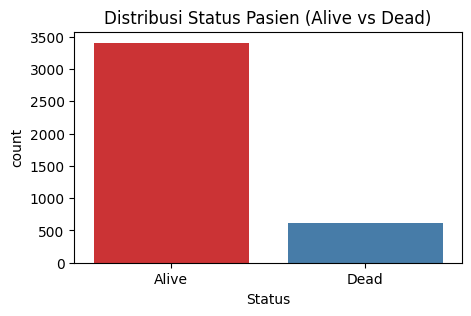

In [ ]:
# 4.1 Memeriksa informasi umum dan tipe data
print("--- Cek Kolom dan Tipe Data ---")
df_raw.info()

print("\n--- Cek Nilai Kosong (Missing Values) ---")
print(df_raw.isnull().sum())

print("\n--- Distribusi Target (Status) ---")
print(df_raw['Status'].value_counts())

# 4.2 Visualisasi Distribusi Target
plt.figure(figsize=(5, 3))
sns.countplot(x='Status', data=df_raw, palette='Set1')
plt.title('Distribusi Status Pasien (Alive vs Dead)')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [ ]:
# Membuat salinan data untuk dibersihkan
df_clean = df_raw.copy()

# 5.1 Menghapus spasi tersembunyi pada nama kolom (jika ada)
df_clean.columns = df_clean.columns.str.strip()

# 5.2 Menghapus baris duplikat jika terdeteksi
if df_clean.duplicated().sum() > 0:
    print(f"Menghapus {df_clean.duplicated().sum()} baris duplikat.")
    df_clean.drop_duplicates(inplace=True)

# 5.3 Encoding Target ('Alive' -> 1, 'Dead' -> 0)
df_clean['Status'] = df_clean['Status'].map({'Alive': 1, 'Dead': 0})

# 5.4 Memisahkan Fitur Kategorikal dan Numerik untuk Encoding
categorical_cols = [
    'Race', 'Marital Status', 'T Stage', 'N Stage', '6th Stage',
    'differentiate', 'Grade', 'A Stage', 'Estrogen Status', 'Progesterone Status'
]
numeric_cols = [
    'Age', 'Tumor Size', 'Regional Node Examined', 'Reginol Node Positive', 'Survival Months'
]

# Menggunakan LabelEncoder untuk kolom kategorikal teks agar menyusut menjadi angka
le = LabelEncoder()
for col in categorical_cols:
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))

# 5.5 Pemisahan Fitur (X) dan Target (y)
X = df_clean.drop(columns=['Status'])
y = df_clean['Status']

# 5.6 Standarisasi Fitur Numerik
scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

# Menggabungkan kembali menjadi satu DataFrame siap pakai
df_preprocessed = X.copy()
df_preprocessed['target'] = y.values

print("Preprocessing Selesai!")
print(f"Dimensi data siap latih: {df_preprocessed.shape}")
df_preprocessed.head()


Menghapus 1 baris duplikat.
Preprocessing Selesai!
Dimensi data siap latih: (4023, 16)


,Age,Race,Marital Status,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,target
0,1.565507,2,1,0,0,0,1,3,1,-1.253728,1,1,1.190429,-0.618278,-0.493093,1
1,-0.442973,2,1,1,1,2,0,2,1,0.214171,1,1,-0.044256,0.164641,-0.405833,1
2,0.449685,2,0,2,2,4,0,2,1,1.540015,1,1,-0.044256,0.556100,0.161353,1
3,0.449685,2,1,0,0,0,1,3,1,-0.590806,1,1,-1.525877,-0.618278,0.554020,1
4,-0.777719,2,1,1,0,1,1,3,1,0.498280,1,1,-1.402409,-0.618278,-0.929390,1
